# Hito 1 Baseline — F1 Race Strategy Advisor

This notebook builds the Hito 1 baseline for the locked target `is_top10`. It follows the locked temporal split: train on 2019-2021, calibrate on 2022, and evaluate once on 2023-2024 after the model is locked.

## Leakage audit

This cell classifies each race-level column before any modeling work. The purpose is to separate information that would be known before the race from information that is only valid as a user-controlled scenario input or as an audit-only outcome. This directly supports the Hito 1 temporal validation and leakage rubric because it prevents post-race information from entering the baseline as if it were known pre-race. The baseline will use `grid_position` as the position feature and may use `constructor_tier` only as coarse pre-race context. This cell deliberately does not train a model, compute metrics, or inspect test performance.

In [1]:
import pandas as pd

RANDOM_SEED = 414
DATA_PATH = "../data/f1_strategy_race_level.csv"

columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()

pre_race_columns = {
    "season",
    "round",
    "race_name",
    "circuit_id",
    "circuit",
    "circuit_type",
    "driver_id",
    "driver_name",
    "Driver",
    "Team",
    "constructor_name",
    "grid_position",
    "qualifying_position",
    "driver_prior3_avg_finish",
    "constructor_prior3_avg_finish",
    "driver_circuit_prior_avg",
    "constructor_tier",
}

scenario_input_columns = {
    "n_stops",
    "strategy_type",
    "compound_sequence",
    "stint_lengths",
    "stint1_length",
    "stint2_length",
    "stint3_length",
    "stint4_length",
    "stint5_length",
    "avg_pit_stop_duration_s",
    "total_pit_time_s",
    "first_pit_lap",
    "last_pit_lap",
}

audit_only_columns = {
    "qualifying_time_s",
    "track_status_summary",
    "safety_car_periods",
    "safety_car_laps",
    "vsc_laps",
    "weather_actual",
    "wet_laps",
    "avg_track_temp",
    "avg_air_temp",
    "dnf",
    "status",
}

target_outcome_columns = {
    "finish_position",
    "points",
    "positions_gained",
    "is_top3",
    "is_top5",
    "is_top10",
}

def classify_column(column):
    if column in pre_race_columns:
        return "pre-race"
    if column in scenario_input_columns:
        return "scenario input"
    if column in audit_only_columns:
        return "audit-only"
    if column in target_outcome_columns:
        return "target/outcome"
    return "unclassified"

leakage_audit = pd.DataFrame({"column": columns})
leakage_audit["classification"] = leakage_audit["column"].map(classify_column)
leakage_audit["hito1_baseline_use"] = leakage_audit["classification"].map({
    "pre-race": "eligible",
    "scenario input": "exclude from baseline; use only for what-if scenarios",
    "audit-only": "exclude from baseline; use only for audits or limitations",
    "target/outcome": "exclude from features",
    "unclassified": "review before use",
})

leakage_audit


,column,classification,hito1_baseline_use
0,season,pre-race,eligible
1,round,pre-race,eligible
2,race_name,pre-race,eligible
3,circuit_id,pre-race,eligible
4,circuit,pre-race,eligible
5,circuit_type,pre-race,eligible
6,driver_id,pre-race,eligible
7,driver_name,pre-race,eligible
8,Driver,pre-race,eligible
9,Team,pre-race,eligible


## Locked temporal split

This cell loads the race-level dataset and applies the locked Hito 1 split: train on 2019-2021, calibrate on 2022, and reserve 2023-2024 as the final test set. The split is temporal because race strategy models should be judged on future seasons, not randomly mixed historical rows. This advances the validation rubric by making the train/calibration/test boundaries explicit before any model fitting. The cell deliberately avoids inspecting test target rates or test metrics, because the test block must remain untouched until the baseline is locked.

In [2]:
df = pd.read_csv(DATA_PATH)

target = "is_top10"
train_df = df[df["season"].between(2019, 2021)].copy()
calibration_df = df[df["season"].eq(2022)].copy()
test_df = df[df["season"].between(2023, 2024)].copy()

split_summary = pd.DataFrame({
    "split": ["train", "calibration", "test"],
    "seasons": ["2019-2021", "2022", "2023-2024"],
    "rows": [len(train_df), len(calibration_df), len(test_df)],
})

development_target_summary = pd.DataFrame({
    "split": ["train", "calibration"],
    "target_rate_is_top10": [
        train_df[target].mean(),
        calibration_df[target].mean(),
    ],
})

display(split_summary)
display(development_target_summary)


,split,seasons,rows
0,train,2019-2021,1132
1,calibration,2022,426
2,test,2023-2024,889


,split,target_rate_is_top10
0,train,0.515018
1,calibration,0.516432


## Grid-only heuristic baseline

This cell defines the Hito 1 baseline as a simple grid-position heuristic. The F1 logic is that drivers starting near the front are more likely to finish in the Top 10, while drivers starting outside the points-paying positions need more overtakes, strategy gains, or attrition to reach the Top 10. This is intentionally a baseline rather than a trained model, so it uses only `grid_position` and fixed probability bands selected before looking at test results. It deliberately excludes strategy columns such as `n_stops`, `strategy_type`, and `compound_sequence`, because those are scenario inputs for what-if comparisons, not pre-race predictors for the Hito 1 baseline.

In [3]:
def grid_position_baseline_proba(grid_position):
    if pd.isna(grid_position):
        return 0.50
    if grid_position <= 5:
        return 0.90
    if grid_position <= 10:
        return 0.70
    if grid_position <= 15:
        return 0.35
    return 0.15

baseline_feature = "grid_position"

train_baseline = train_df.copy()
calibration_baseline = calibration_df.copy()

train_baseline["baseline_raw_proba"] = train_baseline[baseline_feature].map(grid_position_baseline_proba)
calibration_baseline["baseline_raw_proba"] = calibration_baseline[baseline_feature].map(grid_position_baseline_proba)

baseline_band_preview = (
    train_baseline
    .assign(grid_band=pd.cut(
        train_baseline[baseline_feature],
        bins=[0, 5, 10, 15, 25],
        labels=["P1-P5", "P6-P10", "P11-P15", "P16+"],
        include_lowest=True,
    ))
    .groupby("grid_band", observed=False)
    .agg(
        rows=(target, "size"),
        actual_top10_rate=(target, "mean"),
        assigned_probability=("baseline_raw_proba", "mean"),
    )
    .reset_index()
)

baseline_band_preview


,grid_band,rows,actual_top10_rate,assigned_probability
0,P1-P5,285,0.873684,0.90
1,P6-P10,280,0.678571,0.70
2,P11-P15,280,0.357143,0.35
3,P16+,287,0.153310,0.15


## Sigmoid calibration on 2022

This cell calibrates the grid-only baseline using the 2022 calibration block. We use sigmoid/Platt calibration because the calibration season is small, so a smooth two-parameter correction is less likely to overfit than isotonic calibration. This supports the rubric requirement for probability-quality evaluation while preserving the locked temporal split: training logic comes from 2019-2021, calibration mapping comes from 2022, and 2023-2024 remains untouched. The cell deliberately does not tune the grid bands or inspect test results.

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression

epsilon = 1e-6

def probability_to_logit(probability):
    clipped = np.clip(probability, epsilon, 1 - epsilon)
    return np.log(clipped / (1 - clipped))

calibrator = LogisticRegression(random_state=RANDOM_SEED)

X_calibration_raw = probability_to_logit(calibration_baseline[["baseline_raw_proba"]].to_numpy())
y_calibration = calibration_baseline[target].to_numpy()

calibrator.fit(X_calibration_raw, y_calibration)

train_baseline["baseline_calibrated_proba"] = calibrator.predict_proba(
    probability_to_logit(train_baseline[["baseline_raw_proba"]].to_numpy())
)[:, 1]

calibration_baseline["baseline_calibrated_proba"] = calibrator.predict_proba(
    probability_to_logit(calibration_baseline[["baseline_raw_proba"]].to_numpy())
)[:, 1]

calibration_preview = pd.DataFrame({
    "split": ["train", "calibration"],
    "mean_raw_probability": [
        train_baseline["baseline_raw_proba"].mean(),
        calibration_baseline["baseline_raw_proba"].mean(),
    ],
    "mean_calibrated_probability": [
        train_baseline["baseline_calibrated_proba"].mean(),
        calibration_baseline["baseline_calibrated_proba"].mean(),
    ],
    "actual_top10_rate": [
        train_baseline[target].mean(),
        calibration_baseline[target].mean(),
    ],
})

calibration_preview


,split,mean_raw_probability,mean_calibrated_probability,actual_top10_rate
0,train,0.524337,0.519201,0.515018
1,calibration,0.521127,0.516433,0.516432


## Final locked test evaluation

This cell evaluates the locked grid-only baseline on the untouched 2023-2024 test seasons. The baseline bands and sigmoid calibration method were fixed before this cell, so these metrics are final evaluation evidence rather than inputs for tuning. We report Brier score, log loss, ROC-AUC, and a calibration curve because the capstone asks for probability quality, not only classification accuracy. This cell deliberately does not change features, probability bands, or calibration after seeing the test results.

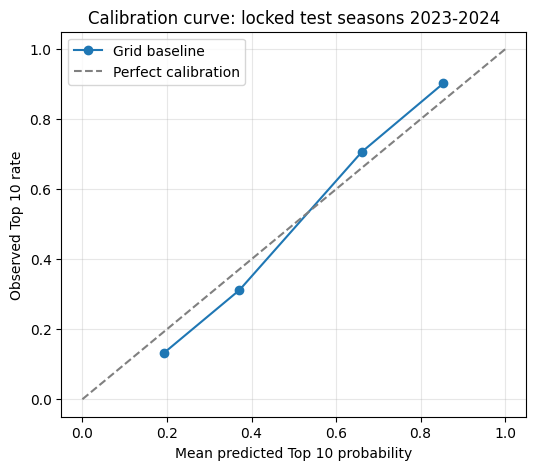

,model,target,test_seasons,brier_score,log_loss,roc_auc,docent_calibrated_brier,docent_calibrated_roc_auc,grid_rule_baseline_brier
0,grid_only_heuristic_sigmoid_calibrated,is_top10,2023-2024,0.158664,0.491975,0.839138,0.132,0.892,0.208


In [5]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

test_baseline = test_df.copy()
test_baseline["baseline_raw_proba"] = test_baseline[baseline_feature].map(grid_position_baseline_proba)
test_baseline["baseline_calibrated_proba"] = calibrator.predict_proba(
    probability_to_logit(test_baseline[["baseline_raw_proba"]].to_numpy())
)[:, 1]

y_test = test_baseline[target]
y_test_proba = test_baseline["baseline_calibrated_proba"]

test_metrics = pd.DataFrame({
    "model": ["grid_only_heuristic_sigmoid_calibrated"],
    "target": [target],
    "test_seasons": ["2023-2024"],
    "brier_score": [brier_score_loss(y_test, y_test_proba)],
    "log_loss": [log_loss(y_test, y_test_proba)],
    "roc_auc": [roc_auc_score(y_test, y_test_proba)],
    "docent_calibrated_brier": [0.132],
    "docent_calibrated_roc_auc": [0.892],
    "grid_rule_baseline_brier": [0.208],
})

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=5,
    strategy="quantile",
)

plt.figure(figsize=(6, 5))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label="Grid baseline")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted Top 10 probability")
plt.ylabel("Observed Top 10 rate")
plt.title("Calibration curve: locked test seasons 2023-2024")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

test_metrics


## First what-if scenario table

This cell records the first planned strategy comparison using a fixed 2024 Dutch Grand Prix driver-race context and two alternative strategy inputs. The purpose is to make the Hito 1 experiment plan concrete: the comparison changes `n_stops`, `strategy_type`, `compound_sequence`, and `stint_lengths` while keeping the driver and circuit context fixed. This supports the rubric requirement for specific what-if scenarios with concrete feature values. The cell deliberately does not use these strategy columns in the Hito 1 baseline model, because they are scenario inputs rather than pre-race baseline predictors.

In [6]:
whatif_scenarios = pd.DataFrame([
    {
        "scenario": "A_one_stop",
        "season": 2024,
        "round": 15,
        "race_name": "Dutch Grand Prix",
        "circuit_id": "zandvoort",
        "circuit_type": "permanent",
        "driver_id": "russell",
        "driver_name": "Russell",
        "Team": "Mercedes",
        "grid_position": 4.0,
        "constructor_tier": "midfield",
        "n_stops": 1,
        "strategy_type": "one_stop",
        "compound_sequence": "M-H",
        "stint_lengths": "25-44",
    },
    {
        "scenario": "B_two_stop",
        "season": 2024,
        "round": 15,
        "race_name": "Dutch Grand Prix",
        "circuit_id": "zandvoort",
        "circuit_type": "permanent",
        "driver_id": "russell",
        "driver_name": "Russell",
        "Team": "Mercedes",
        "grid_position": 4.0,
        "constructor_tier": "midfield",
        "n_stops": 2,
        "strategy_type": "two_stop",
        "compound_sequence": "M-H-S",
        "stint_lengths": "23-27-17",
    },
])

whatif_scenarios


,scenario,season,round,race_name,circuit_id,circuit_type,driver_id,driver_name,Team,grid_position,constructor_tier,n_stops,strategy_type,compound_sequence,stint_lengths
0,A_one_stop,2024,15,Dutch Grand Prix,zandvoort,permanent,russell,Russell,Mercedes,4.0,midfield,1,one_stop,M-H,25-44
1,B_two_stop,2024,15,Dutch Grand Prix,zandvoort,permanent,russell,Russell,Mercedes,4.0,midfield,2,two_stop,M-H-S,23-27-17
